In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import RFE

from copy import deepcopy
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.feature_selection import RFE
import numpy as np
import pandas as pd
from copy import deepcopy


In [75]:
def load_tcga_kidney_cohort(expr_path, pheno_path, cohort_name, tumor_class):
    """
    expr_path  : path to HiSeqV2 expression file
    pheno_path : path to clinicalMatrix file
    cohort_name: 'KIRC', 'KIRP' or 'KICH'
    tumor_class: 1 for KIRC, 2 for KIRP, 3 for KICH
    """

    # 1) Expression
    expr = pd.read_csv(expr_path, sep="\t", index_col=0)

    # 2) Phenotype
    pheno = pd.read_csv(pheno_path, sep="\t")

    # 3) Keep only Primary Tumor + Solid Tissue Normal
    pheno = pheno[pheno["sample_type"].isin(["Primary Tumor", "Solid Tissue Normal"])].copy()

    # 4) Add cohort + numeric class
    pheno["cohort"] = cohort_name
    pheno["class"] = np.where(pheno["sample_type"] == "Solid Tissue Normal",
                              0,              # class 0 = normal
                              tumor_class)    # 1/2/3 for cancer types

    # 5) Keep only samples that exist in expression matrix
    pheno = pheno[pheno["sampleID"].isin(expr.columns)].copy()
    expr = expr.loc[:, pheno["sampleID"]]

    print(f"{cohort_name} expr shape:", expr.shape)
    print(f"{cohort_name} pheno shape:", pheno.shape)
    print(pheno["sample_type"].value_counts(), "\n")

    return expr, pheno


In [76]:
# ---- KIRC ----
kirc_expr, kirc_pheno = load_tcga_kidney_cohort(
    expr_path="TCGA.KIRC.sampleMap_HiSeqV2.gz",
    pheno_path="TCGA.KIRC.sampleMap_KIRC_clinicalMatrix",
    cohort_name="KIRC",
    tumor_class=1
)

# ---- KIRP ----
kirp_expr, kirp_pheno = load_tcga_kidney_cohort(
    expr_path="TCGA.KIRP.sampleMap_HiSeqV2.gz",
    pheno_path="TCGA.KIRP.sampleMap_KIRP_clinicalMatrix",
    cohort_name="KIRP",
    tumor_class=2
)

# ---- KICH ----
kich_expr, kich_pheno = load_tcga_kidney_cohort(
    expr_path="TCGA.KICH.sampleMap_HiSeqV2.gz",
    pheno_path="TCGA.KICH.sampleMap_KICH_clinicalMatrix",
    cohort_name="KICH",
    tumor_class=3
)


KIRC expr shape: (20530, 605)
KIRC pheno shape: (605, 114)
sample_type
Primary Tumor          533
Solid Tissue Normal     72
Name: count, dtype: int64 

KIRP expr shape: (20530, 322)
KIRP pheno shape: (322, 111)
sample_type
Primary Tumor          290
Solid Tissue Normal     32
Name: count, dtype: int64 

KICH expr shape: (20530, 91)
KICH pheno shape: (91, 93)
sample_type
Primary Tumor          66
Solid Tissue Normal    25
Name: count, dtype: int64 



In [77]:
kirc_pheno_clean = kirc_pheno[
    kirc_pheno["sampleID"].isin(kirc_expr.columns)
]

kirc_pheno_clean = kirc_pheno_clean[
    kirc_pheno_clean["sample_type"].isin(["Primary Tumor", "Solid Tissue Normal"])
].copy()

kirc_pheno_clean["cohort"] = "KIRC"

kirc_pheno_clean["class"] = np.where(
    kirc_pheno_clean["sample_type"] == "Solid Tissue Normal",
    0,
    1
)

kirc_expr_clean = kirc_expr.loc[:, kirc_pheno_clean["sampleID"]]

print("Expr shape:", kirc_expr_clean.shape)

print("Pheno shape:", kirc_pheno_clean.shape)
print(kirc_pheno_clean["class"].value_counts())

kirc_pheno_clean["sample_type"].value_counts()

Expr shape: (20530, 605)
Pheno shape: (605, 114)
class
1    533
0     72
Name: count, dtype: int64


sample_type
Primary Tumor          533
Solid Tissue Normal     72
Name: count, dtype: int64

In [78]:
kirp_pheno_clean = kirp_pheno[
    kirp_pheno["sampleID"].isin(kirp_expr.columns)
]

kirp_pheno_clean = kirp_pheno_clean[
    kirp_pheno_clean["sample_type"].isin(["Primary Tumor", "Solid Tissue Normal"])
].copy()

kirp_pheno_clean["cohort"] = "KIRP"

kirp_pheno_clean["class"] = np.where(
    kirp_pheno_clean["sample_type"] == "Solid Tissue Normal",
    0,
    2
)

kirp_expr_clean = kirp_expr.loc[:, kirp_pheno_clean["sampleID"]]

print("Expr shape:", kirp_expr_clean.shape)

print("Pheno shape:", kirp_pheno_clean.shape)
print(kirp_pheno_clean["class"].value_counts())

kirp_pheno_clean["sample_type"].value_counts()

Expr shape: (20530, 322)
Pheno shape: (322, 111)
class
2    290
0     32
Name: count, dtype: int64


sample_type
Primary Tumor          290
Solid Tissue Normal     32
Name: count, dtype: int64

In [79]:
kich_pheno_clean = kich_pheno[
    kich_pheno["sampleID"].isin(kich_expr.columns)
]

kich_pheno_clean = kich_pheno_clean[
    kich_pheno_clean["sample_type"].isin(["Primary Tumor", "Solid Tissue Normal"])
].copy()

kich_pheno_clean["cohort"] = "KIRP"

kich_pheno_clean["class"] = np.where(
    kich_pheno_clean["sample_type"] == "Solid Tissue Normal",
    0,
    3
)

kich_expr_clean = kich_expr.loc[:, kich_pheno_clean["sampleID"]]

print("Expr shape:", kich_expr_clean.shape)

print("Pheno shape:", kich_pheno_clean.shape)
print(kich_pheno_clean["class"].value_counts())

kich_pheno_clean["sample_type"].value_counts()

Expr shape: (20530, 91)
Pheno shape: (91, 93)
class
3    66
0    25
Name: count, dtype: int64


sample_type
Primary Tumor          66
Solid Tissue Normal    25
Name: count, dtype: int64

In [80]:
common_genes = kirc_expr_clean.index.intersection(kirp_expr_clean.index).intersection(kich_expr_clean.index)

# Keep only shared genes
kirc_expr_final = kirc_expr_clean.loc[common_genes]
kirp_expr_final = kirp_expr_clean.loc[common_genes]
kich_expr_final = kich_expr_clean.loc[common_genes]

# Concatenate across samples (columns)
expr_all = pd.concat([kirc_expr_final, kirp_expr_final, kich_expr_final], axis=1)
print("Combined expression shape:", expr_all.shape)


Combined expression shape: (20530, 1018)


Combine phenotypes

In [81]:
pheno_all = pd.concat([kirc_pheno_clean, kirp_pheno_clean, kich_pheno_clean], ignore_index=True)
print("Combined phenotype shape:", pheno_all.shape)
print(pheno_all["class"].value_counts())


Combined phenotype shape: (1018, 161)
class
1    533
2    290
0    129
3     66
Name: count, dtype: int64


ensure the order of samples is consistent between expr_all and pheno_all

In [82]:
expr_all = expr_all.loc[:, pheno_all["sampleID"]]


In [83]:
# Copy expression data (samples × genes)
df_all = expr_all.T.copy()

# Add the class column (from phenotype table)
df_all["class"] = pheno_all["class"].values

# Check result
print(df_all.shape)
df_all.head()


(1018, 20531)


sample,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS,class
TCGA-3Z-A93Z-01,10.2510,6.3672,0.0000,11.5988,11.1267,10.6054,12.0332,6.1801,0.0000,6.0080,...,4.7398,6.0220,3.9475,9.6599,13.3097,10.9736,11.6569,5.4890,10.4792,1
TCGA-6D-AA2E-01,10.9708,6.5183,0.6226,11.8937,11.0113,11.1812,12.8435,4.5647,0.6226,5.4651,...,6.7311,4.0575,4.2334,9.3685,11.9694,8.0581,12.1499,7.6680,10.1044,1
TCGA-A3-3306-01,10.1293,4.8295,0.0000,10.6479,11.9086,11.5827,12.0497,2.2089,1.0252,2.8502,...,0.0000,4.2171,0.0000,10.5636,12.2014,9.1010,11.8201,5.2384,10.3869,1
TCGA-A3-3307-01,9.8124,7.7373,0.0000,11.6015,11.6806,11.3954,12.4619,3.9708,0.5447,5.4483,...,3.5299,5.6196,3.6401,9.7827,12.8778,10.3088,11.4826,7.2384,10.2740,1
TCGA-A3-3308-01,10.4740,6.2437,0.0000,11.6695,11.6121,10.5021,12.0858,6.1160,0.9392,6.0575,...,5.3218,5.6197,4.6878,9.7394,13.2476,10.4814,10.7198,8.9449,9.5017,1


## Prepare for ML

In [ ]:
X = df_all.drop(columns='class')    #(.copy())
y = df_all['class']

In [85]:
print(X.shape, y.shape)

(1018, 20530) (1018,)


## Data visualisation

C:\Users\HP\AppData\Local\Temp\ipykernel_8752\594481354.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="class", y="Expression", data=df_melt, palette="Set2")


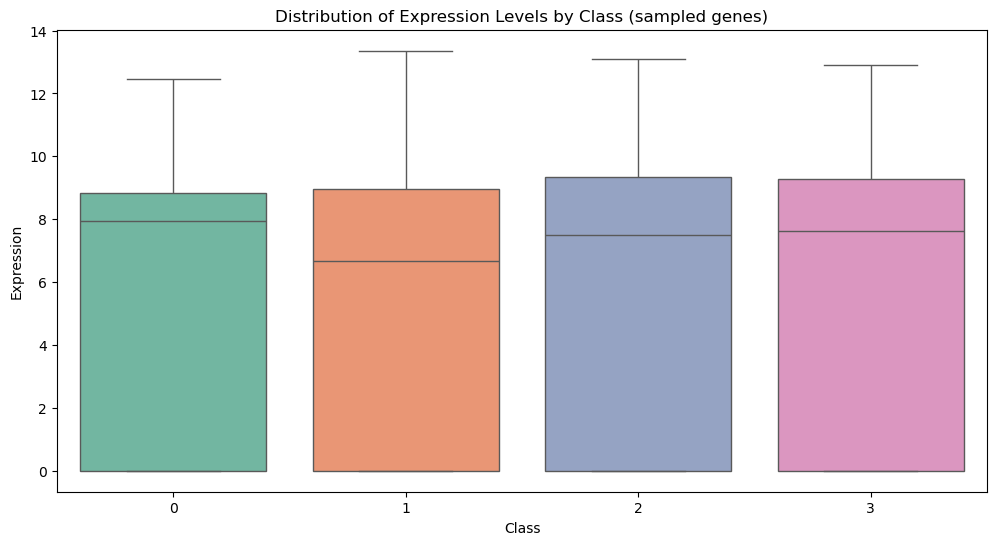

In [86]:
# We’ll take a random subset of genes to avoid overcrowding
np.random.seed(42)
genes_to_plot = np.random.choice(df_all.columns[:-1], size=10, replace=False)

# Melt the dataframe for seaborn (tidy format)
df_melt = df_all.melt(id_vars="class", value_vars=genes_to_plot,
                      var_name="Gene", value_name="Expression")

# Boxplot by class
plt.figure(figsize=(12,6))
sns.boxplot(x="class", y="Expression", data=df_melt, palette="Set2")
plt.title("Distribution of Expression Levels by Class (sampled genes)")
plt.xlabel("Class")
plt.ylabel("Expression")
plt.show()

Explained variance ratio: [0.13971214 0.11205959 0.06374286]


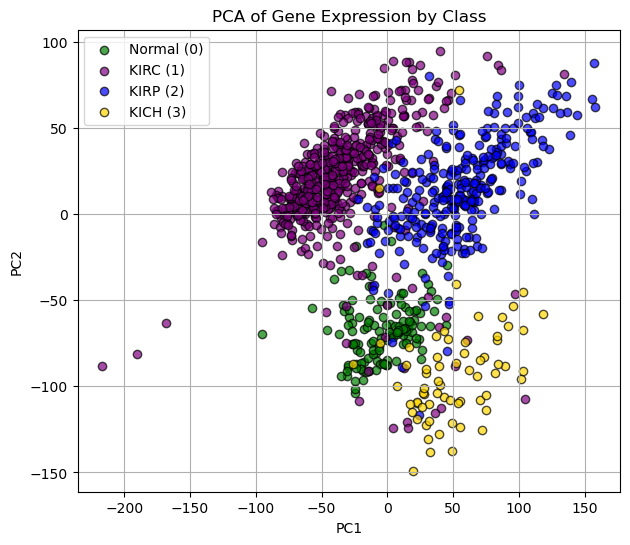

In [87]:
# 2️⃣ Standardize the data (important before PCA)
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)
# convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# 3️⃣ Apply PCA (2 components for visualization)
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# 4️⃣ Plot the PCA with color per class
plt.figure(figsize=(7,6))
colors = ['green', 'purple', 'blue', 'gold']
labels = ['Normal (0)', 'KIRC (1)', 'KIRP (2)', 'KICH (3)']

for i, color in enumerate(colors):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1],
                c=color, label=labels[i], alpha=0.7, edgecolor='k')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Gene Expression by Class')
plt.legend()
plt.grid(True)
plt.show()

In [88]:
print(pca.explained_variance_ratio_)

[0.13971214 0.11205959 0.06374286]


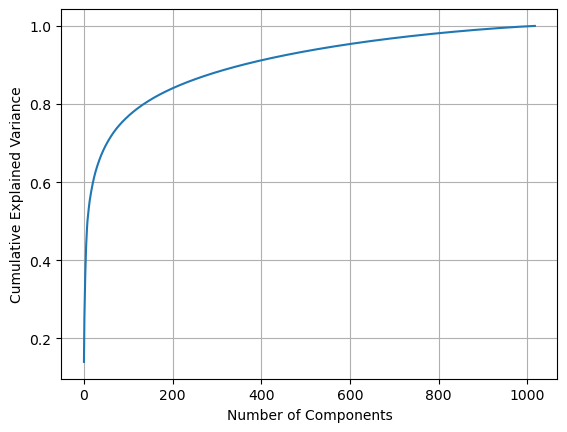

In [89]:
pca_full = PCA().fit(X_scaled)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

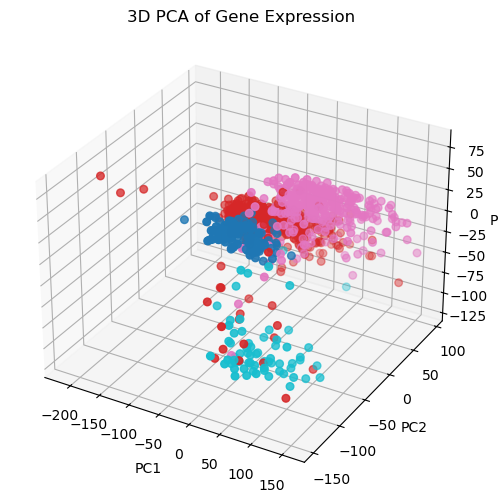

In [90]:
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=y, cmap='tab10', s=30)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
plt.title('3D PCA of Gene Expression')
plt.show()

# LOGISTIC REGRESSION

## Train model split

In [91]:
# Shuffle and split your data (X = features, y = labels)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (814, 20530)
Test shape: (204, 20530)


## Beginning to do the (RFE Recursive feature elimination) with LR

In [92]:
# 1) Définir le modèle de base
log_reg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000,
    n_jobs=-1
)


In [93]:
# 2) Créer l'objet RFE : on demande 300 gènes
rfe = RFE(
    estimator=log_reg,
    n_features_to_select=300,  # tu peux changer ce nombre
    step=0.1                   # enlève 10% des features à chaque itération
)

# 3) Lancer RFE sur TOUTES les données scalées
rfe.fit(X_scaled, y)


c:\Users\HP\anaconda3\envs\pycoding\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\HP\anaconda3\envs\pycoding\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\HP\anaconda3\envs\pycoding\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\HP\anaconda3\envs\pycoding\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWar

RFE(estimator=LogisticRegression(max_iter=2000, multi_class='multinomial',
                                 n_jobs=-1),
    n_features_to_select=300, step=0.1)

In [94]:
# 4) Récupérer les gènes sélectionnés
selected_mask = rfe.support_                  # booléen True/False par gène
selected_genes = X.columns[selected_mask]     # noms des gènes gardés


X_rfe_scaled = X_scaled[selected_genes]

print("Shape original :", X_scaled.shape)     # (n_samples, ~20530)
print("Shape RFE      :", X_rfe_scaled.shape) # (n_samples, 300)

Shape original : (1018, 20530)
Shape RFE      : (1018, 300)


## Train Logistic regression on those 300 genes we choosed

In [137]:
# X_rfe_scaled is a DataFrame (1018, 300)
# y must be aligned with it (length 1018)
X_train, X_test, y_train, y_test = train_test_split(
    X_rfe_scaled,
    y,
    test_size=0.2,          # 20% test
    stratify=y,             # keep same class proportions
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((814, 300), (204, 300), (814,), (204,))

In [139]:
log_reg = LogisticRegression(
    multi_class="multinomial",   # true multi-class
    solver="lbfgs",
    max_iter=2000,
    n_jobs=-1                      # use all cores if possible
)

log_reg.fit(X_train, y_train)

c:\Users\HP\anaconda3\envs\pycoding\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=2000, multi_class='multinomial', n_jobs=-1)

Test accuracy (LogReg, 300 genes): 0.990

Classification report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.98      0.99       107
           2       0.98      1.00      0.99        58
           3       1.00      1.00      1.00        13

    accuracy                           0.99       204
   macro avg       0.99      1.00      0.99       204
weighted avg       0.99      0.99      0.99       204



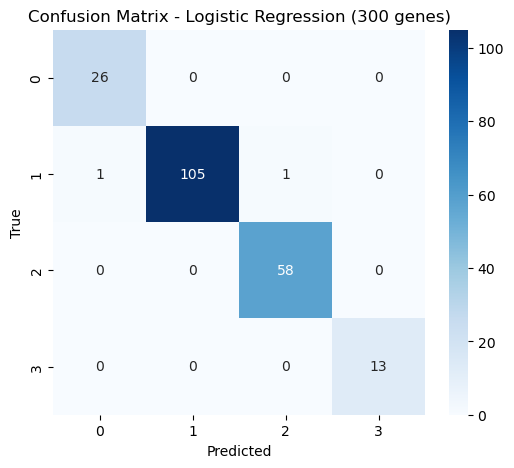

In [ ]:
# predictions
y_pred = log_reg.predict(X_test)


# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy (LogReg, 300 genes): {acc:.3f}")

# Detailed metrics per class
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Logistic Regression (300 genes)")
plt.show()

In [ ]:
# Coeff matrix shape: (n_classes, n_features)
coef = log_reg.coef_    # 4 x 300

# Overall importance = average |coef| over classes
importance = np.mean(np.abs(coef), axis=0)

genes_importance = pd.DataFrame({
    "gene": X_rfe_scaled.columns,
    "importance": importance
}).sort_values("importance", ascending=False)

genes_importance.head(20)

,gene,importance
88,CALCA,0.111362
89,CUL9,0.107846
152,HEXIM1,0.104925
170,CP,0.101677
136,FGF10,0.101064
109,TRPV5,0.099789
114,WDR92,0.098098
211,KRT24,0.093458
142,FABP7,0.091679
294,POLE3,0.089434


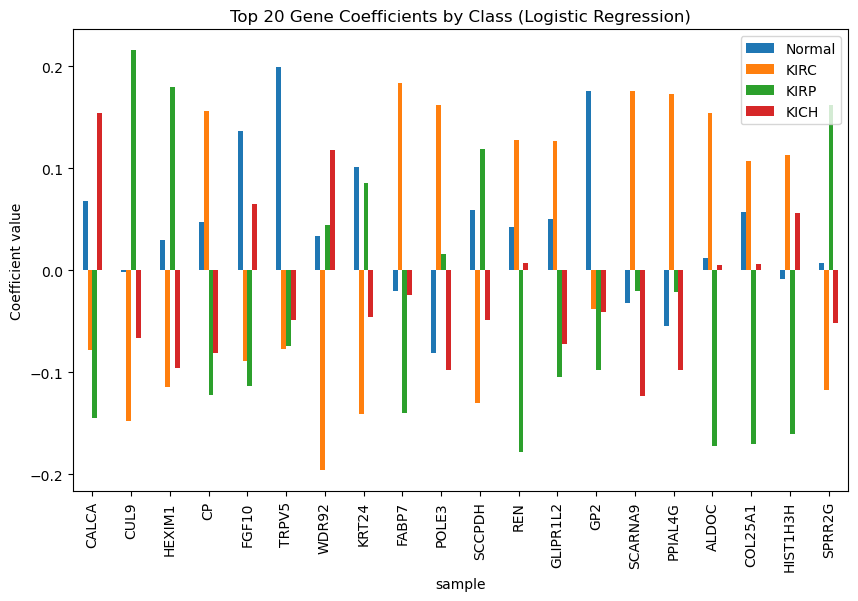

In [ ]:
top_genes = genes_importance.head(20)['gene']
coef_df = pd.DataFrame(log_reg.coef_, columns=X_rfe_scaled.columns, index=['Normal','KIRC','KIRP','KICH'])
coef_df[top_genes].T.plot(kind='bar', figsize=(10,6))
plt.title("Top 20 Gene Coefficients by Class (Logistic Regression)")
plt.ylabel("Coefficient value")
plt.show()

###  Using 20 genes

In [ ]:
# Select the top 20 genes from your previous ranking
top20_genes = genes_importance.head(20)['gene'].tolist()

# Filter your scaled data to keep only these genes
X_top20 = X_scaled[top20_genes]
print(X_top20.shape)  # should be (1018, 20)


(1018, 20)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_top20, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
log_reg_20 = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000
)

log_reg_20.fit(X_train, y_train)

c:\Users\HP\anaconda3\envs\pycoding\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=2000, multi_class='multinomial')

Accuracy (LogReg, 20 genes): 0.9362745098039216

Classification Report:
               precision    recall  f1-score   support

           0       0.87      1.00      0.93        26
           1       0.97      0.93      0.95       107
           2       0.92      0.95      0.93        58
           3       0.92      0.85      0.88        13

    accuracy                           0.94       204
   macro avg       0.92      0.93      0.92       204
weighted avg       0.94      0.94      0.94       204



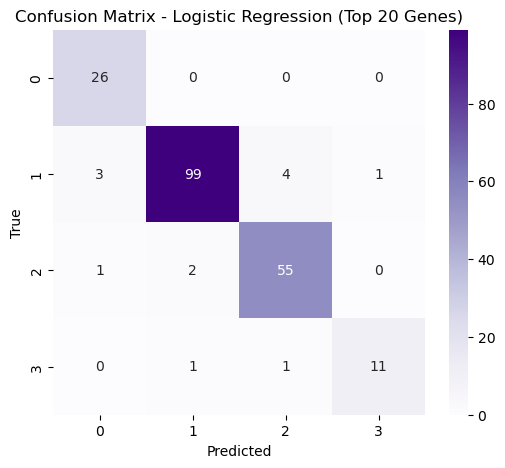

In [ ]:

y_pred = log_reg_20.predict(X_test)

print("Accuracy (LogReg, 20 genes):", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[0,1,2,3],
            yticklabels=[0,1,2,3])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Logistic Regression (Top 20 Genes)")
plt.show()

### 

###  5 GENES

In [154]:
# Select the top 5 genes from your previous ranking
top5_genes = genes_importance.head(5)['gene'].tolist()
print(top5_genes)

# Filter your scaled data to keep only these genes
X_top5 = X_scaled[top5_genes]
print(X_top5.shape)  # should be (1018, 5)

['CALCA', 'CUL9', 'HEXIM1', 'CP', 'FGF10']
(1018, 5)


c:\Users\HP\anaconda3\envs\pycoding\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy (LogReg, 5 genes): 0.8676470588235294

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94        26
           1       0.88      0.93      0.90       107
           2       0.82      0.81      0.82        58
           3       0.78      0.54      0.64        13

    accuracy                           0.87       204
   macro avg       0.86      0.80      0.82       204
weighted avg       0.87      0.87      0.86       204



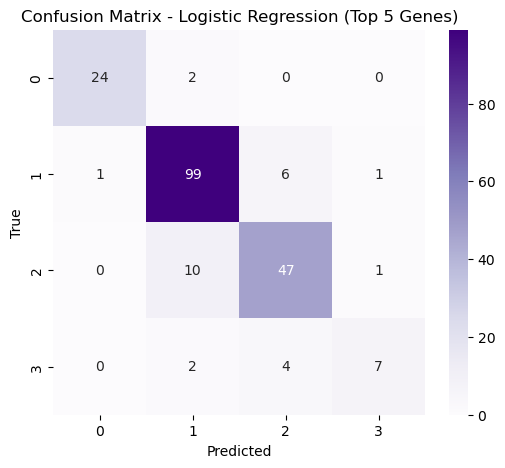

In [156]:
X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(
    X_top5, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 4) Train logistic regression on 5 genes
log_reg_5 = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000
)

log_reg_5.fit(X_train_5, y_train_5)

# 5) Predictions & metrics
y_pred_5 = log_reg_5.predict(X_test_5)

print("Accuracy (LogReg, 5 genes):", accuracy_score(y_test_5, y_pred_5))
print("\nClassification Report:\n", classification_report(y_test_5, y_pred_5))

# 6) Confusion matrix
cm = confusion_matrix(y_test_5, y_pred_5)



plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Purples",
    xticklabels=[0,1,2,3],
    yticklabels=[0,1,2,3]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Logistic Regression (Top 5 Genes)")
plt.show()

### REF 1 GENE

In [155]:
# Select the top 5 genes from your previous ranking
top1_genes = genes_importance.head(1)['gene'].tolist()
print(top1_genes)

# Filter your scaled data to keep only these genes
X_top1 = X_scaled[top1_genes]
print(X_top1.shape)  

['CALCA']
(1018, 1)


c:\Users\HP\anaconda3\envs\pycoding\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\HP\anaconda3\envs\pycoding\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3\envs\pycoding\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3\envs\pycoding\lib

Accuracy (LogReg, 1 genes): 0.6225490196078431

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.85      0.76        26
           1       0.61      0.98      0.75       107
           2       0.00      0.00      0.00        58
           3       0.00      0.00      0.00        13

    accuracy                           0.62       204
   macro avg       0.32      0.46      0.38       204
weighted avg       0.41      0.62      0.49       204



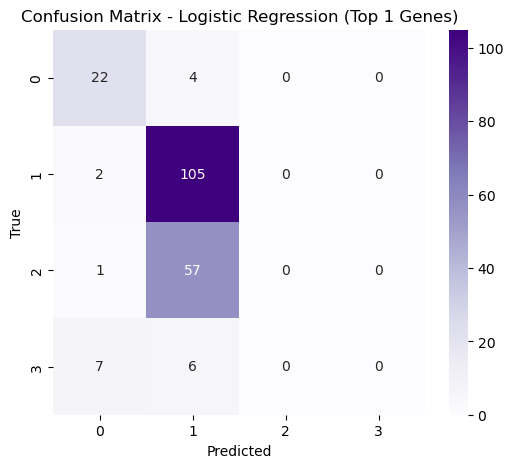

In [157]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_top1, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 4) Train logistic regression on 5 genes
log_reg_1 = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000
)

log_reg_1.fit(X_train_1, y_train_1)

# 5) Predictions & metrics
y_pred_1 = log_reg_1.predict(X_test_1)

print("Accuracy (LogReg, 1 genes):", accuracy_score(y_test_1, y_pred_1))
print("\nClassification Report:\n", classification_report(y_test_1, y_pred_1))

# 6) Confusion matrix
cm = confusion_matrix(y_test_1, y_pred_1)



plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Purples",
    xticklabels=[0,1,2,3],
    yticklabels=[0,1,2,3]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Logistic Regression (Top 1 Genes)")
plt.show()

## RANDOM FOREST 

In [111]:
# in order to test the different trees 

for n in [50, 100, 200, 500]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train_rf, y_train_rf)
    print(f"{n} trees → accuracy = {rf.score(X_test_rf, y_test_rf):.3f}")


50 trees → accuracy = 0.951
100 trees → accuracy = 0.951
200 trees → accuracy = 0.946
500 trees → accuracy = 0.946


In [116]:
# 1️⃣ Define model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2️⃣ Apply RFE to select top features (e.g., 300 genes)
rfe_rf = RFE(estimator=rf_model, n_features_to_select=300)
rfe_rf.fit(X_scaled, y)

# 3️⃣ Extract selected features
selected_mask_rf = rfe_rf.support_
selected_genes_rf = X.columns[selected_mask_rf]
X_rf_scaled = X_scaled[selected_genes_rf]

print("✅ Shape after RFE (Random Forest):", X_rf_scaled.shape)
print("Top selected genes:", selected_genes_rf[:20].tolist())

# 4️⃣ Split data
from sklearn.model_selection import train_test_split
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf_scaled, y, test_size=0.3, stratify=y, random_state=42
)

# 5️⃣ Train model
rf_model.fit(X_train_rf, y_train_rf)

# 6️⃣ Evaluate performance
y_pred_rf = rf_model.predict(X_test_rf)

✅ Shape after RFE (Random Forest): (1018, 300)
Top selected genes: ['FAM115C', 'JAGN1', 'OVOL1', 'RNF208', 'PLXNB2', 'METRNL', 'KBTBD6', 'SLCO1C1', 'BAP1', 'FAM3B', 'MTUS1', 'ADRA1D', 'RAB11FIP4', 'RPA2', 'TMEM91', 'FGL2', 'SIRT5', 'PVT1', 'SPP1', 'UCP3']


Test Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        39
           1       0.97      0.94      0.96       160
           2       0.91      0.97      0.94        87
           3       0.80      0.80      0.80        20

    accuracy                           0.94       306
   macro avg       0.91      0.91      0.91       306
weighted avg       0.94      0.94      0.94       306



<Axes: >

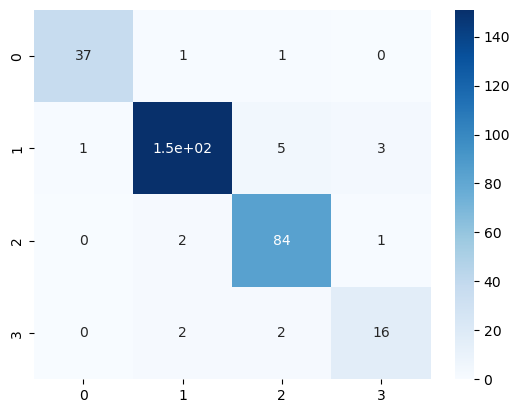

In [117]:
print("Test Accuracy:", accuracy_score(y_test_rf, y_pred_rf))
print(classification_report(y_test_rf, y_pred_rf))
sns.heatmap(confusion_matrix(y_test_rf, y_pred_rf), annot=True, cmap="Blues")

In [118]:
# Use the same train/test split as before
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf_scaled, y, test_size=0.3, stratify=y, random_state=42
)


In [122]:
# Define list of gene counts to test
gene_counts = [300, 250, 200, 150, 100, 80, 60, 40, 30, 20, 10, 5, 1]

# Store results
results = []

for n in gene_counts:
    # Subset top n genes from the RFE-RF list
    top_genes = selected_genes_rf[:n]
    X_train_sub = X_train_rf[top_genes]
    X_test_sub = X_test_rf[top_genes]

    # Train a smaller Random Forest
    model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(X_train_sub, y_train_rf)
    
    # Evaluate
    y_pred = model.predict(X_test_sub)
    acc = accuracy_score(y_test_rf, y_pred)
    f1 = f1_score(y_test_rf, y_pred, average='weighted')
    results.append((n, acc, f1))
    print(f"{n} genes → Accuracy: {acc:.3f}, F1: {f1:.3f}")




300 genes → Accuracy: 0.948, F1: 0.948
250 genes → Accuracy: 0.941, F1: 0.941
200 genes → Accuracy: 0.944, F1: 0.944
150 genes → Accuracy: 0.944, F1: 0.944
100 genes → Accuracy: 0.941, F1: 0.941
80 genes → Accuracy: 0.948, F1: 0.947
60 genes → Accuracy: 0.938, F1: 0.938
40 genes → Accuracy: 0.951, F1: 0.951
30 genes → Accuracy: 0.938, F1: 0.938
20 genes → Accuracy: 0.944, F1: 0.945
10 genes → Accuracy: 0.928, F1: 0.928
5 genes → Accuracy: 0.873, F1: 0.871
1 genes → Accuracy: 0.699, F1: 0.698


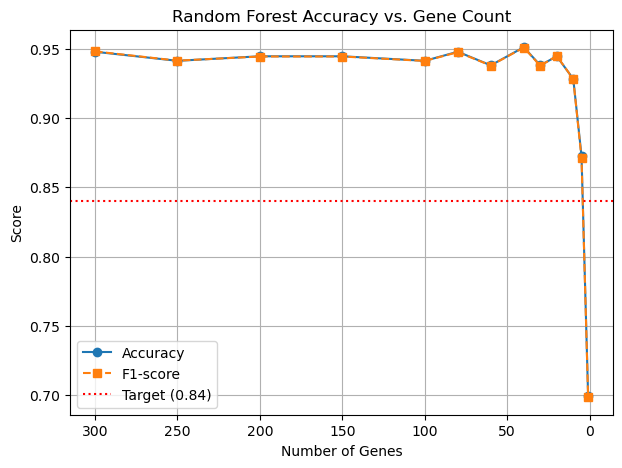

In [124]:
# Convert to DataFrame for plotting
results_df = pd.DataFrame(results, columns=["Genes", "Accuracy", "F1"])
# Plot accuracy vs. number of genes
plt.figure(figsize=(7,5))
plt.plot(results_df["Genes"], results_df["Accuracy"], marker="o", color="#1f77b4", label="Accuracy")
plt.plot(results_df["Genes"], results_df["F1"], marker="s", linestyle="--", color="#ff7f0e", label="F1-score")
plt.axhline(0.84, color="red", linestyle=":", label="Target (0.84)")
plt.gca().invert_xaxis()  # decreasing number of genes left to right
plt.title("Random Forest Accuracy vs. Gene Count")
plt.xlabel("Number of Genes")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()


### Ran Fores with only 20 genes

In [127]:

# 2. RFE pour sélectionner les 20 meilleurs gènes
rfe_rf_20 = RFE(estimator=rf_model, n_features_to_select=20, step=0.1)
rfe_rf_20.fit(X_scaled, y)

# 3. Extraire les gènes sélectionnés
selected_mask_20 = rfe_rf_20.support_
selected_genes_rf20 = X.columns[selected_mask_20]
X_rf20_scaled = X_scaled[selected_genes_rf20]

print("✅ Shape after RFE (20 genes):", X_rf20_scaled.shape)
print("Top 20 genes (Random Forest RFE):", selected_genes_rf20.tolist())


✅ Shape after RFE (20 genes): (1018, 20)
Top 20 genes (Random Forest RFE): ['GJC1', 'SAP30', 'TMCC1', 'STC2', 'GABRD', 'NPTX2', 'CSPG4', 'CA9', 'FABP7', 'SFRP1', 'EGLN3', 'ATP6V1G3', 'GPR116', 'OLFML2A', 'CNTN1', 'VWA5B1', 'VEGFA', 'NETO2', 'DHX30', 'ENPP3']


🔹 Test Accuracy: 0.9313725490196079

               precision    recall  f1-score   support

           0       0.97      0.97      0.97        39
           1       0.98      0.93      0.95       160
           2       0.87      0.97      0.91        87
           3       0.79      0.75      0.77        20

    accuracy                           0.93       306
   macro avg       0.90      0.90      0.90       306
weighted avg       0.93      0.93      0.93       306



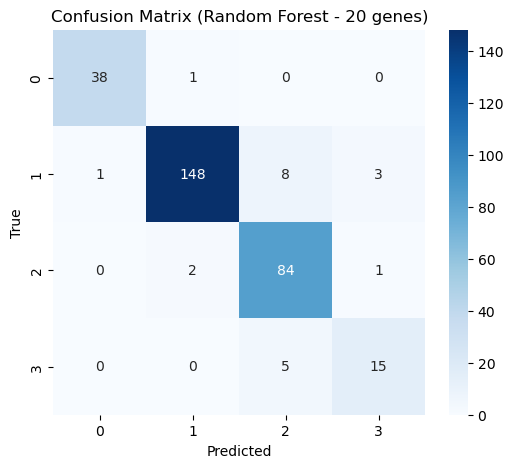

In [128]:
# Split des données
X_train_rf20, X_test_rf20, y_train_rf20, y_test_rf20 = train_test_split(
    X_rf20_scaled, y, test_size=0.3, stratify=y, random_state=42
)

# Entraînement
rf_model.fit(X_train_rf20, y_train_rf20)

# Prédiction
y_pred_rf20 = rf_model.predict(X_test_rf20)

# Rapport et matrice
print("🔹 Test Accuracy:", rf_model.score(X_test_rf20, y_test_rf20))
print("\n", classification_report(y_test_rf20, y_pred_rf20))

cm = confusion_matrix(y_test_rf20, y_pred_rf20)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Random Forest - 20 genes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


### TOP 5 GENES RAN FOREST

In [132]:
# 2. RFE pour sélectionner les 5 meilleurs gènes
rfe_rf_5 = RFE(estimator=rf_model, n_features_to_select=5, step=0.1)
rfe_rf_5.fit(X_scaled, y)

# 3. Extraire les gènes sélectionnés
selected_mask_5 = rfe_rf_5.support_
selected_genes_rf5 = X.columns[selected_mask_5]
X_rf5_scaled = X_scaled[selected_genes_rf5]

print("✅ Shape after RFE (5 genes):", X_rf5_scaled.shape)
print("Top 5 genes (Random Forest RFE):", selected_genes_rf5.tolist())

✅ Shape after RFE (5 genes): (1018, 5)
Top 5 genes (Random Forest RFE): ['SAP30', 'GABRD', 'NPTX2', 'EGLN3', 'VEGFA']


🔹 Test Accuracy: 0.8921568627450981

               precision    recall  f1-score   support

           0       0.85      0.87      0.86        39
           1       0.96      0.92      0.94       160
           2       0.83      0.90      0.86        87
           3       0.74      0.70      0.72        20

    accuracy                           0.89       306
   macro avg       0.84      0.85      0.84       306
weighted avg       0.89      0.89      0.89       306



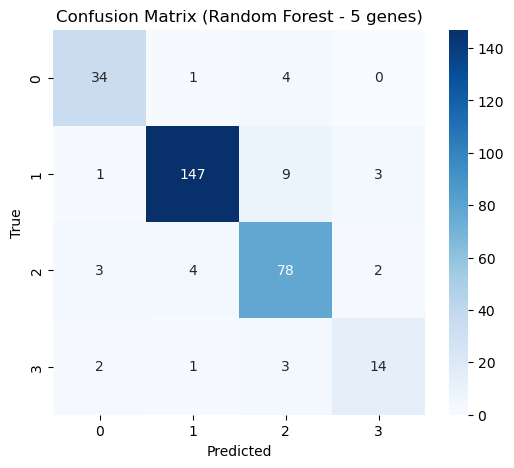

In [133]:
# Split des données
X_train_rf5, X_test_rf5, y_train_rf5, y_test_rf5 = train_test_split(
    X_rf5_scaled, y, test_size=0.3, stratify=y, random_state=42
)

# Entraînement
rf_model.fit(X_train_rf5, y_train_rf5)

# Prédiction
y_pred_rf5 = rf_model.predict(X_test_rf5)

# Rapport et matrice
print("🔹 Test Accuracy:", rf_model.score(X_test_rf5, y_test_rf5))
print("\n", classification_report(y_test_rf5, y_pred_rf5))

cm = confusion_matrix(y_test_rf5, y_pred_rf5)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Random Forest - 5 genes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


### TOP 1 GENE RAN FOREST

In [135]:
# 2. RFE pour sélectionner les 5 meilleurs gènes
rfe_rf_1 = RFE(estimator=rf_model, n_features_to_select=1, step=0.1)
rfe_rf_1.fit(X_scaled, y)

# 3. Extraire les gènes sélectionnés
selected_mask_1 = rfe_rf_1.support_
selected_genes_rf1 = X.columns[selected_mask_1]
X_rf1_scaled = X_scaled[selected_genes_rf1]

print("✅ Shape after RFE (1 genes):", X_rf1_scaled.shape)
print("Top 1 genes (Random Forest RFE):", selected_genes_rf1.tolist())

✅ Shape after RFE (1 genes): (1018, 1)
Top 1 genes (Random Forest RFE): ['NPTX2']


🔹 Test Accuracy: 0.6503267973856209

               precision    recall  f1-score   support

           0       0.23      0.18      0.20        39
           1       0.89      0.88      0.88       160
           2       0.52      0.57      0.54        87
           3       0.10      0.10      0.10        20

    accuracy                           0.65       306
   macro avg       0.43      0.43      0.43       306
weighted avg       0.65      0.65      0.65       306



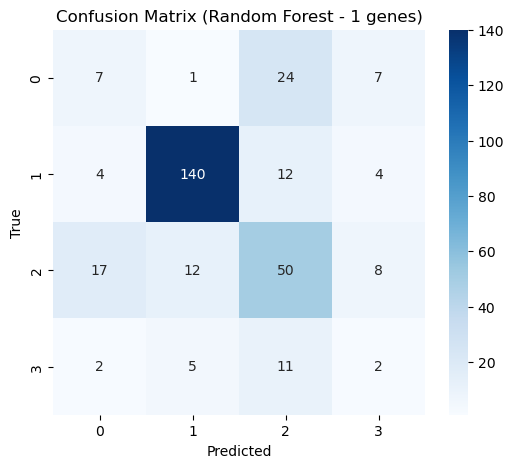

In [136]:
# Split des données
X_train_rf1, X_test_rf1, y_train_rf1, y_test_rf1 = train_test_split(
    X_rf1_scaled, y, test_size=0.3, stratify=y, random_state=42
)

# Entraînement
rf_model.fit(X_train_rf1, y_train_rf5)

# Prédiction
y_pred_rf1 = rf_model.predict(X_test_rf1)

# Rapport et matrice
print("🔹 Test Accuracy:", rf_model.score(X_test_rf1, y_test_rf1))
print("\n", classification_report(y_test_rf1, y_pred_rf1))

cm = confusion_matrix(y_test_rf1, y_pred_rf1)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Random Forest - 1 genes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()